## Figure 2 {q, p} phase space plot corresponding to different energy levels.

In [26]:
import utils
import functions
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import hnn
from configs import CONFIGS

config = CONFIGS["LHNN_1DGaussianmixture"]
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("mymodel.weights.h5")
# model_path = "mymodel.weights.h5"
# model = tf.keras.models.load_model(model_path)

initial_state = np.zeros(2)


timegrad_fn = utils.get_timegrad_fn(functions.functions("1D_Gauss_mix"))
states_numgrad, states_lhnn = [], []
for idx in range(9):
    initial_state[1] = 1/3 * (idx+1)
    states_numgrad.append(utils.get_trajectory(timegrad_fn, initial_state=initial_state, dt=0.05, num_lf=200,require_grads=False)[0])
    states_lhnn.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=200,require_grads=False)[0])



In [21]:
model.get_gradient(tf.convert_to_tensor(initial_state.reshape(1,-1), dtype=tf.float32)).numpy().flatten()

array([1.8645673, 4.8799887], dtype=float32)

In [22]:
timegrad_fn(initial_state)

array([ 3., -0.])

In [24]:
loss = []
for x,y in zip(states_lhnn, states_numgrad):
    loss.append(np.mean((x-y)**2))
np.mean(loss)

np.float64(1.4822814445241532)

In [25]:
loss

[np.float64(0.022481682178105346),
 np.float64(0.024688472555608226),
 np.float64(0.031059142586335613),
 np.float64(0.05020432393000194),
 np.float64(0.043495567262381934),
 np.float64(0.005503910263208132),
 np.float64(0.29845328963659234),
 np.float64(2.746278282341125),
 np.float64(10.11836832996402)]

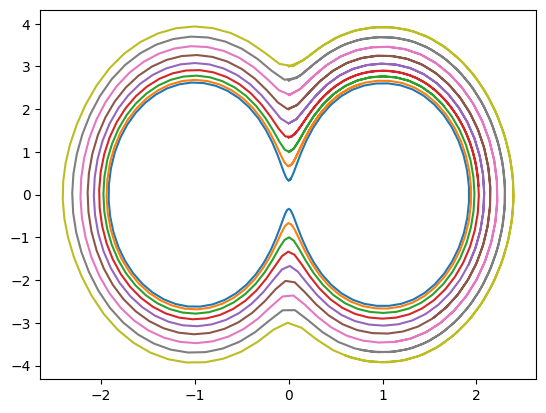

In [35]:
# for states in states_numgrad:
#     plt.plot(states[:200,0], states[:200,1])
for states in states_lhnn:
    plt.plot(states[:100,0], states[:100,1])

In [6]:
model.get_gradient(tf.convert_to_tensor(initial_state.reshape(1,-1), dtype=tf.float32)).numpy().flatten()

array([1.8645673, 4.8799887], dtype=float32)

In [11]:
states_numgrad

(array([[ 0.00000000e+00,  4.74795529e-01],
        [ 2.37397765e-02,  5.09012706e-01],
        [ 5.09012706e-02,  6.13076574e-01],
        [ 8.50474339e-02,  7.88161499e-01],
        [ 1.29717420e-01,  1.02718174e+00],
        [ 1.87765608e-01,  1.30854204e+00],
        [ 2.60571625e-01,  1.60130772e+00],
        [ 3.47896380e-01,  1.87818884e+00],
        [ 4.48390509e-01,  2.12218604e+00],
        [ 5.60114984e-01,  2.32421836e+00],
        [ 6.80812345e-01,  2.47908150e+00],
        [ 8.08023134e-01,  2.58339395e+00],
        [ 9.39151741e-01,  2.63499007e+00],
        [ 1.07152214e+00,  2.63281162e+00],
        [ 1.20243290e+00,  2.57690242e+00],
        [ 1.32921238e+00,  2.46840338e+00],
        [ 1.44927324e+00,  2.30952876e+00],
        [ 1.56016526e+00,  2.10352091e+00],
        [ 1.65962533e+00,  1.85458405e+00],
        [ 1.74562366e+00,  1.56779854e+00],
        [ 1.81640519e+00,  1.24901714e+00],
        [ 1.87052538e+00,  9.04745600e-01],
        [ 1.90687975e+00,  5.420

In [11]:
model.summary()

Model: "hnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,700 (80.86 KB)

 Trainable params: 20,700 (80.86 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.get_gradient

<bound method HNN.get_gradient of <HNN name=hnn, built=False>>